# 04 — Modeling

Wildfires Susceptibility Mapping — Córdoba, Argentina

Inputs: `data/processed/train.csv`, `data/processed/test.csv`, `data/processed/selected_features.json`

Sections:
1. Setup & data loading
2. MLflow experiment init
3. 10-fold CV helper
4. Baseline models (RF, XGBoost, LightGBM)
5. Comparison table & ROC curves
6. Best model selection

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, roc_curve, confusion_matrix,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import mlflow
import mlflow.sklearn

sns.set_theme(style='whitegrid', font_scale=1.1)

PROCESSED   = Path('../data/processed')
OUTPUTS     = Path('../outputs')
MODELS_DIR  = Path('../models')
MLRUNS_DIR  = Path('../mlruns')
OUTPUTS.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42
CV_FOLDS     = 10
EXPERIMENT   = 'wildfires-cordoba'

print('All imports OK')

All imports OK


## 1. Load Data

In [2]:
with open(PROCESSED / 'selected_features.json') as f:
    feature_meta = json.load(f)

MODEL_FEATURES = feature_meta['all_model_features']

train = pd.read_csv(PROCESSED / 'train.csv')
test  = pd.read_csv(PROCESSED / 'test.csv')

X_train = train[MODEL_FEATURES].values
y_train = train['label'].values
X_test  = test[MODEL_FEATURES].values
y_test  = test['label'].values

print(f'Train: {X_train.shape}  |  fire rate: {y_train.mean():.4f}')
print(f'Test : {X_test.shape}   |  fire rate: {y_test.mean():.4f}')
print(f'Features ({len(MODEL_FEATURES)}): {MODEL_FEATURES}')

Train: (50607, 20)  |  fire rate: 0.5000
Test : (21689, 20)   |  fire rate: 0.5000
Features (20): ['elevation', 'slope', 'aspect_cos', 'lst', 'population_density', 'clay', 'distance_to_road_km', 'distance_to_river_km', 'distance_to_settlement_km', 'lc_20', 'lc_30', 'lc_40', 'lc_50', 'lc_60', 'lc_80', 'lc_90', 'lc_114', 'lc_116', 'lc_124', 'lc_126']


## 2. MLflow Setup

In [3]:
mlflow.set_tracking_uri(f'file://{MLRUNS_DIR.resolve()}')
mlflow.set_experiment(EXPERIMENT)

exp = mlflow.get_experiment_by_name(EXPERIMENT)
print(f'Experiment: {EXPERIMENT}')
print(f'Tracking URI: {mlflow.get_tracking_uri()}')
print(f'Experiment ID: {exp.experiment_id}')

2026/04/06 10:26:08 INFO mlflow.tracking.fluent: Experiment with name 'wildfires-cordoba' does not exist. Creating a new experiment.


Experiment: wildfires-cordoba
Tracking URI: file:///Users/gerardoaboulafia/Library/Mobile Documents/com~apple~CloudDocs/UCA/Documentos/Cuatrimestre 7/Labo III/Wildfires/mlruns
Experiment ID: 310954585512672985


## 3. Evaluation Helper

In [4]:
CV = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

SCORING = {
    'roc_auc'  : 'roc_auc',
    'accuracy' : 'accuracy',
    'precision': 'precision',
    'recall'   : 'recall',
    'f1'       : 'f1',
}

def evaluate_on_test(model, X_test, y_test):
    """Return dict of holdout metrics for a fitted model."""
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = model.predict(X_test)
    return {
        'test_roc_auc'  : roc_auc_score(y_test, y_prob),
        'test_accuracy' : accuracy_score(y_test, y_pred),
        'test_precision': precision_score(y_test, y_pred, zero_division=0),
        'test_recall'   : recall_score(y_test, y_pred, zero_division=0),
        'test_f1'       : f1_score(y_test, y_pred, zero_division=0),
    }


def train_and_log(name, model, X_train, y_train, X_test, y_test, run_tags=None):
    """
    Run 10-fold CV + holdout evaluation, log to MLflow, return results dict.
    """
    print(f'Training {name}...', end=' ', flush=True)
    
    cv_results = cross_validate(
        model, X_train, y_train,
        cv=CV, scoring=SCORING,
        return_train_score=False,
        n_jobs=-1
    )
    
    # Fit on full training set for holdout eval
    model.fit(X_train, y_train)
    holdout = evaluate_on_test(model, X_test, y_test)
    
    cv_auc_mean = cv_results['test_roc_auc'].mean()
    cv_auc_std  = cv_results['test_roc_auc'].std()
    print(f'CV AUC={cv_auc_mean:.4f} ± {cv_auc_std:.4f}  |  Test AUC={holdout["test_roc_auc"]:.4f}')
    
    # Log to MLflow
    with mlflow.start_run(run_name=f'{name}_baseline') as run:
        mlflow.set_tag('phase', 'baseline')
        mlflow.set_tag('model', name)
        if run_tags:
            mlflow.set_tags(run_tags)
        
        # Log params
        for k, v in model.get_params().items():
            mlflow.log_param(k, v)
        
        # Log CV metrics
        for metric in SCORING:
            mlflow.log_metric(f'cv_{metric}_mean', cv_results[f'test_{metric}'].mean())
            mlflow.log_metric(f'cv_{metric}_std',  cv_results[f'test_{metric}'].std())
        
        # Log holdout metrics
        for k, v in holdout.items():
            mlflow.log_metric(k, v)
        
        # Log model artifact
        mlflow.sklearn.log_model(model, artifact_path='model')
        run_id = run.info.run_id
    
    return {
        'name'         : name,
        'model'        : model,
        'run_id'       : run_id,
        'cv_auc_mean'  : cv_auc_mean,
        'cv_auc_std'   : cv_auc_std,
        'cv_acc_mean'  : cv_results['test_accuracy'].mean(),
        'cv_prec_mean' : cv_results['test_precision'].mean(),
        'cv_rec_mean'  : cv_results['test_recall'].mean(),
        'cv_f1_mean'   : cv_results['test_f1'].mean(),
        **holdout
    }

print('Helper functions defined.')

Helper functions defined.


## 4. Baseline Models

Default hyperparameters — no tuning yet. Goal is to establish AUC baselines.

In [5]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    n_jobs=-1,
    random_state=RANDOM_STATE
)

result_rf = train_and_log('RandomForest', rf, X_train, y_train, X_test, y_test)

Training RandomForest... 

CV AUC=0.9965 ± 0.0004  |  Test AUC=0.9973


2026/04/06 10:26:44 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/06 10:26:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [6]:
# XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=RANDOM_STATE
)

result_xgb = train_and_log('XGBoost', xgb, X_train, y_train, X_test, y_test)

Training XGBoost... 

2026/04/06 10:26:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/06 10:26:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


CV AUC=0.9908 ± 0.0007  |  Test AUC=0.9917


In [7]:
# LightGBM
lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=-1
)

result_lgbm = train_and_log('LightGBM', lgbm, X_train, y_train, X_test, y_test)

Training LightGBM... 

CV AUC=0.9961 ± 0.0005  |  Test AUC=0.9967


2026/04/06 10:27:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/04/06 10:27:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


## 5. Comparison Table & Plots

In [8]:
results = [result_rf, result_xgb, result_lgbm]

metrics_df = pd.DataFrame([{
    'Model'         : r['name'],
    'CV AUC'        : f"{r['cv_auc_mean']:.4f} ± {r['cv_auc_std']:.4f}",
    'CV Acc'        : f"{r['cv_acc_mean']:.4f}",
    'CV Prec'       : f"{r['cv_prec_mean']:.4f}",
    'CV Rec'        : f"{r['cv_rec_mean']:.4f}",
    'CV F1'         : f"{r['cv_f1_mean']:.4f}",
    'Test AUC'      : f"{r['test_roc_auc']:.4f}",
    'Test Acc'      : f"{r['test_accuracy']:.4f}",
    'Test F1'       : f"{r['test_f1']:.4f}",
} for r in results])

metrics_df.set_index('Model', inplace=True)
print('=== BASELINE MODEL COMPARISON ===')
print(metrics_df.to_string())
metrics_df

=== BASELINE MODEL COMPARISON ===
                       CV AUC  CV Acc CV Prec  CV Rec   CV F1 Test AUC Test Acc Test F1
Model                                                                                  
RandomForest  0.9965 ± 0.0004  0.9687  0.9838  0.9531  0.9682   0.9973   0.9734  0.9730
XGBoost       0.9908 ± 0.0007  0.9540  0.9750  0.9319  0.9530   0.9917   0.9576  0.9566
LightGBM      0.9961 ± 0.0005  0.9732  0.9869  0.9592  0.9729   0.9967   0.9748  0.9744


,CV AUC,CV Acc,CV Prec,CV Rec,CV F1,Test AUC,Test Acc,Test F1
Model,,,,,,,,
RandomForest,0.9965 ± 0.0004,0.9687,0.9838,0.9531,0.9682,0.9973,0.9734,0.9730
XGBoost,0.9908 ± 0.0007,0.9540,0.9750,0.9319,0.9530,0.9917,0.9576,0.9566
LightGBM,0.9961 ± 0.0005,0.9732,0.9869,0.9592,0.9729,0.9967,0.9748,0.9744


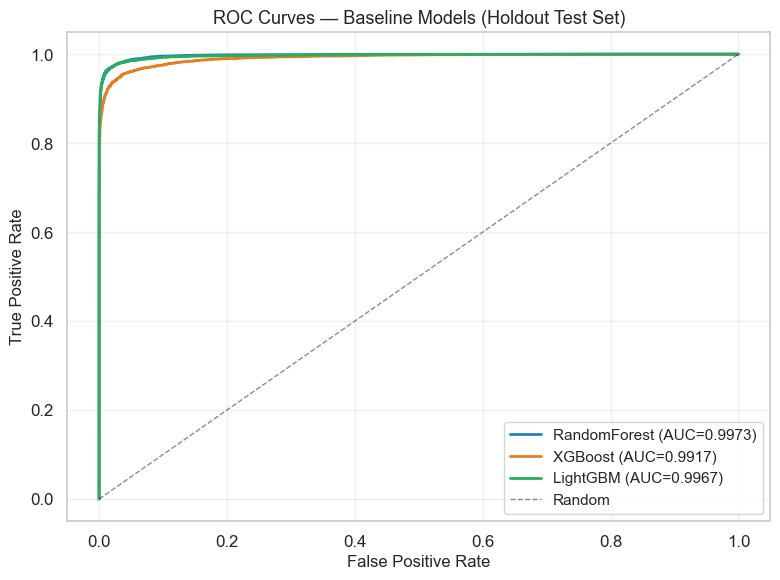

In [9]:
# ROC curves (all models on holdout test set)
fig, ax = plt.subplots(figsize=(8, 6))

colors = ['#2980b9', '#e67e22', '#27ae60']
for r, color in zip(results, colors):
    y_prob = r['model'].predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = r['test_roc_auc']
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{r['name']} (AUC={auc:.4f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Baseline Models (Holdout Test Set)', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS / 'baseline_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

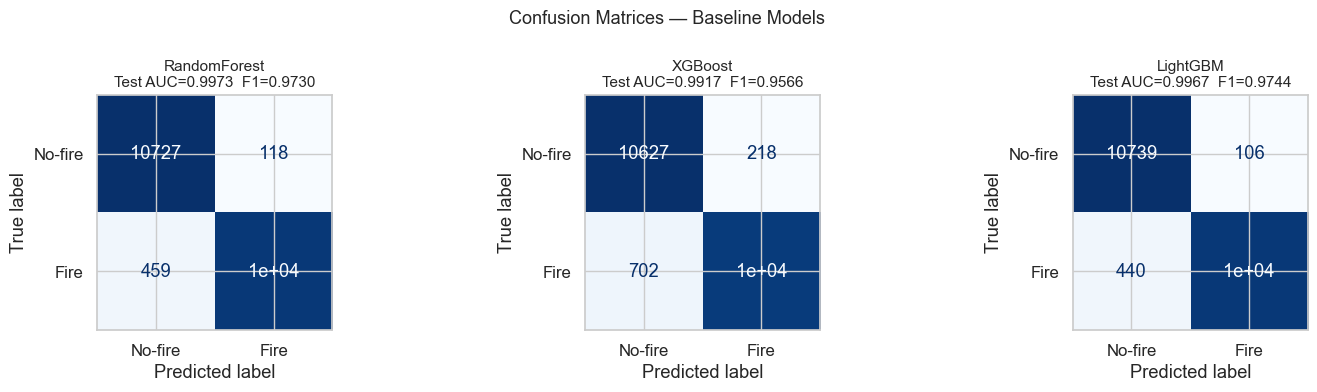

In [10]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for r, ax in zip(results, axes):
    y_pred = r['model'].predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No-fire', 'Fire'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{r['name']}\nTest AUC={r['test_roc_auc']:.4f}  F1={r['test_f1']:.4f}", fontsize=11)

plt.suptitle('Confusion Matrices — Baseline Models', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUTS / 'baseline_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

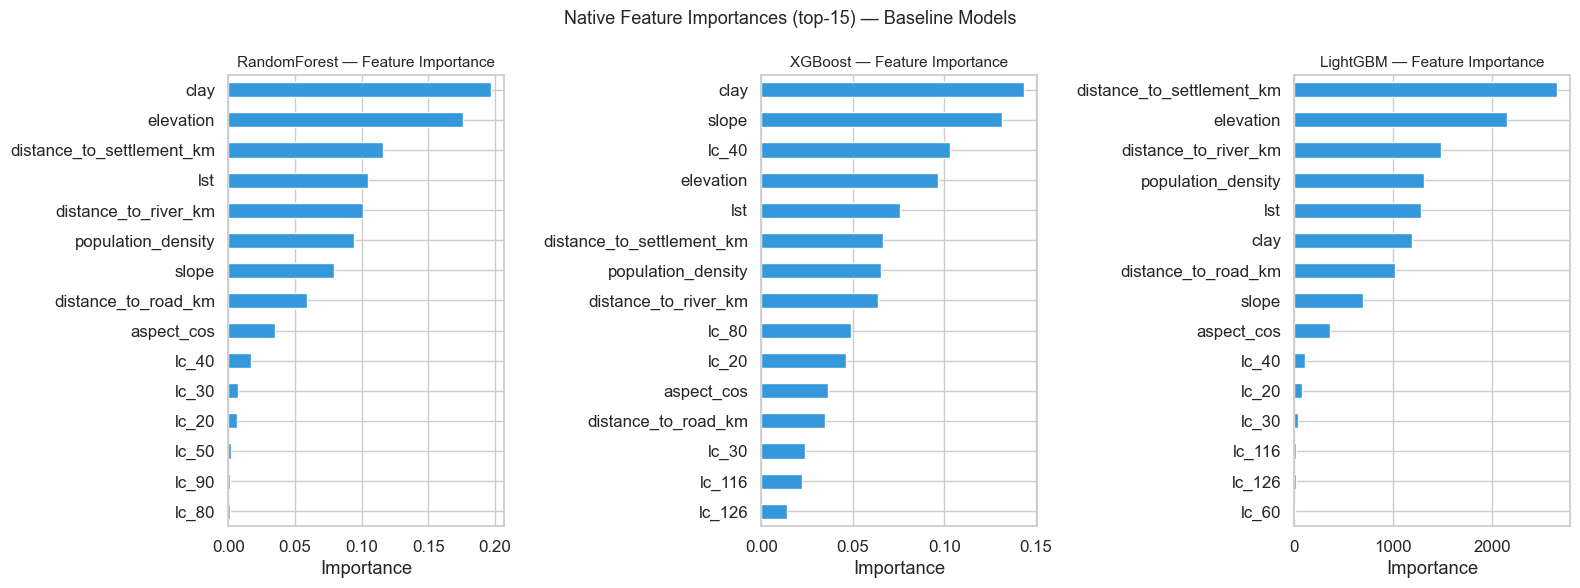

In [11]:
# Feature importance (model-native: impurity for RF, gain for XGB/LGBM)
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for r, ax in zip(results, axes):
    model = r['model']
    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
    else:
        imp = np.zeros(len(MODEL_FEATURES))
    
    imp_df = pd.Series(imp, index=MODEL_FEATURES).sort_values(ascending=True).tail(15)
    imp_df.plot(kind='barh', ax=ax, color='#3498db')
    ax.set_title(f"{r['name']} — Feature Importance", fontsize=11)
    ax.set_xlabel('Importance')

plt.suptitle('Native Feature Importances (top-15) — Baseline Models', fontsize=13)
plt.tight_layout()
plt.savefig(OUTPUTS / 'baseline_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Best Baseline Model Selection

In [12]:
best = max(results, key=lambda r: r['test_roc_auc'])

print(f'Best baseline model: {best["name"]}')
print(f'  Test AUC-ROC : {best["test_roc_auc"]:.4f}')
print(f'  Test Accuracy: {best["test_accuracy"]:.4f}')
print(f'  Test F1      : {best["test_f1"]:.4f}')
print(f'  CV AUC       : {best["cv_auc_mean"]:.4f} ± {best["cv_auc_std"]:.4f}')
print(f'  MLflow run_id: {best["run_id"]}')

# Overfitting check: CV AUC vs test AUC
for r in results:
    delta = abs(r['cv_auc_mean'] - r['test_roc_auc'])
    flag = '  ⚠ possible overfit' if delta > 0.02 else '  OK'
    print(f'  {r["name"]}: |CV_AUC - Test_AUC| = {delta:.4f}{flag}')

Best baseline model: RandomForest
  Test AUC-ROC : 0.9973
  Test Accuracy: 0.9734
  Test F1      : 0.9730
  CV AUC       : 0.9965 ± 0.0004
  MLflow run_id: e6b331dd90c446e0b17b69f6c0b64f29
  RandomForest: |CV_AUC - Test_AUC| = 0.0008  OK
  XGBoost: |CV_AUC - Test_AUC| = 0.0009  OK
  LightGBM: |CV_AUC - Test_AUC| = 0.0006  OK


In [13]:
# Save all baseline models
for r in results:
    model_path = MODELS_DIR / f'{r["name"].lower()}_baseline.pkl'
    with open(model_path, 'wb') as f:
        pickle.dump(r['model'], f)
    print(f'Saved: {model_path}')

# Save metrics summary
summary = [{
    'model': r['name'],
    'cv_auc_mean' : r['cv_auc_mean'],
    'cv_auc_std'  : r['cv_auc_std'],
    'test_roc_auc': r['test_roc_auc'],
    'test_accuracy': r['test_accuracy'],
    'test_precision': r['test_precision'],
    'test_recall'  : r['test_recall'],
    'test_f1'      : r['test_f1'],
    'run_id'       : r['run_id'],
} for r in results]

with open(OUTPUTS / 'baseline_metrics.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('Saved: outputs/baseline_metrics.json')

Saved: ../models/randomforest_baseline.pkl
Saved: ../models/xgboost_baseline.pkl
Saved: ../models/lightgbm_baseline.pkl
Saved: outputs/baseline_metrics.json


## 7. Phase 4A Verification

In [14]:
print('=== PHASE 4A VERIFICATION ===')

# All models exceed AUC > 0.75 (sanity floor for a baseline)
for r in results:
    assert r['test_roc_auc'] > 0.75, f'{r["name"]} AUC too low: {r["test_roc_auc"]:.4f}'
    print(f'  [OK] {r["name"]} test AUC = {r["test_roc_auc"]:.4f} > 0.75')

# Literature benchmark target: >0.85
print()
above_target = [r for r in results if r['test_roc_auc'] > 0.85]
if above_target:
    for r in above_target:
        print(f'  [TARGET MET] {r["name"]} AUC={r["test_roc_auc"]:.4f} > 0.85 (literature benchmark)')
else:
    print(f'  [INFO] No model exceeds 0.85 yet — hyperparameter tuning needed (Phase 4B)')

# All model files saved
for r in results:
    p = MODELS_DIR / f'{r["name"].lower()}_baseline.pkl'
    assert p.exists()
    print(f'  [OK] {p.name} saved')

# MLflow runs logged
client = mlflow.tracking.MlflowClient()
runs = client.search_runs(experiment_ids=[exp.experiment_id], filter_string="tags.phase = 'baseline'")
print(f'  [OK] {len(runs)} MLflow baseline runs logged')

print()
print(f'Best model: {best["name"]} (Test AUC={best["test_roc_auc"]:.4f})')
print('Proceed to Phase 4B: Optuna hyperparameter tuning')

=== PHASE 4A VERIFICATION ===
  [OK] RandomForest test AUC = 0.9973 > 0.75
  [OK] XGBoost test AUC = 0.9917 > 0.75
  [OK] LightGBM test AUC = 0.9967 > 0.75

  [TARGET MET] RandomForest AUC=0.9973 > 0.85 (literature benchmark)
  [TARGET MET] XGBoost AUC=0.9917 > 0.85 (literature benchmark)
  [TARGET MET] LightGBM AUC=0.9967 > 0.85 (literature benchmark)
  [OK] randomforest_baseline.pkl saved
  [OK] xgboost_baseline.pkl saved
  [OK] lightgbm_baseline.pkl saved


  [OK] 3 MLflow baseline runs logged

Best model: RandomForest (Test AUC=0.9973)
Proceed to Phase 4B: Optuna hyperparameter tuning
